In [1]:
import sys
import os
os.chdir('/zhome/71/c/146676/main/')
import time
import SimpleITK as sitk
import numpy as np
from astropy.io import fits
from helpers import module_auxiliary as ma
import tifffile
from multiprocessing import Pool
import matplotlib.pyplot as plt
from helpers import extended_data as ed
from cil.recon import FBP
#from cil.plugins.astra import FBP
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.optimisation.functions import L2NormSquared, L1Norm, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares
from cil.optimisation.operators import BlockOperator, GradientOperator, IdentityOperator, FiniteDifferenceOperator
from cil.optimisation.algorithms import CGLS, SIRT, GD, FISTA, ISTA, PDHG, SPDHG
from cil.plugins.astra.operators import ProjectionOperator
from cil.optimisation.functions import IndicatorBox, MixedL21Norm, L2NormSquared, \
                                       BlockFunction, L1Norm, LeastSquares, \
                                       OperatorCompositionFunction, TotalVariation, \
                                       ZeroFunction
from cil.optimisation.operators import BlockOperator, GradientOperator,\
                                       GradientOperator
import h5py
from cil.utilities.display import show_geometry

In [ ]:
c0 = 50
c1 = 52

y0 = 130
y1 = 230

pad = 30

In [3]:
# Open the h5 file in read mode
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_ct_integrated/scan-0339_pilatus_integrated.h5', 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dataset = file['entry']['data1d']['I'][:][:,c0:c1]  # Replace 'your_dataset' with the actual name of the dataset
    dataset  = dataset.reshape(181, 362, c1-c0).transpose([2,0,1])
    two_theta = file['entry']['data1d']['2th'][:]

#### Data seems to be symmetric in the sense that no center of rotation offset is needed in the reocnstruction.

-12


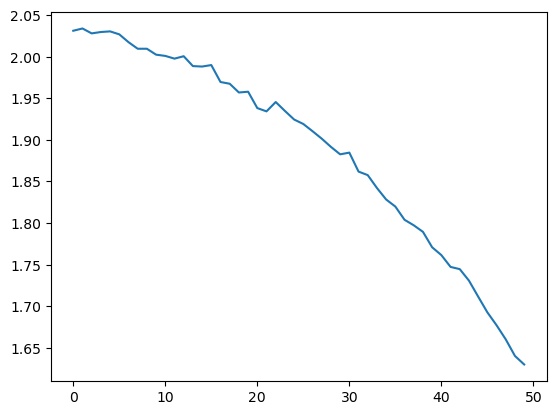

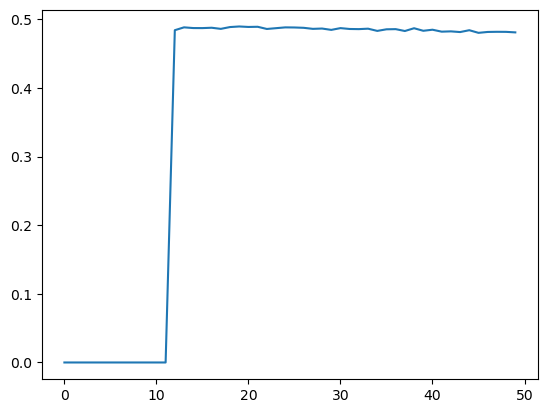

In [4]:
cor_offset_array = np.arange(-12,12,24)
diffs = np.empty(np.shape(cor_offset_array))
for i in range(len(cor_offset_array)):
    offset = cor_offset_array[i]
    A = dataset[0]
    B_moved = np.zeros(np.shape(A))
    B = np.flipud(dataset[-1])[offset:] if offset>=0 else np.flipud(dataset[-1])[:offset]
    if offset>0:
        B_moved[:-offset] = B
    else:
        B_moved[-offset:] = B
    print(offset)
    plt.plot(np.mean(A,axis=1)[:50])
    plt.show()
    plt.plot(np.mean(B_moved,axis=1)[:50])
    plt.show()

    diffs[i] = np.mean((A-B_moved)**2)
I = np.argmin(diffs)
cor_offset = cor_offset_array[I]




In [5]:
def zero_pad_3d(array: np.ndarray, N: int,value=0) -> np.ndarray:
    """
    Pads a 3D NumPy array with zeros along the last two dimensions by N pixels.
    The first dimension (axis=0) remains unchanged.

    Parameters:
    array (np.ndarray): Input 3D array.
    N (int): Number of pixels to pad along the last two dimensions.

    Returns:
    np.ndarray: Zero-padded 3D array.
    """
    if N < 0:
        raise ValueError("Padding size N must be non-negative")
    
    pad_width = ((0, 0), (0, 0), (N, N))  # No padding on axis=0, N on other axes
    return np.pad(array, pad_width, mode='constant', constant_values=0)

# Example usage:
dataset_ = zero_pad_3d(dataset, pad)

In [6]:
from scipy.ndimage import uniform_filter1d
from cil.processors import Slicer
data = dataset_
#data = uniform_filter1d(dataset_, size=5, axis=0, mode='nearest')
nchannels,ntheta, nx = np.shape(dataset)
nchannels,ntheta, nx_ = np.shape(dataset_)
recon = np.zeros((nchannels, y1-y0, nx))
angles = range(0,ntheta)

ag = AcquisitionGeometry.create_Parallel2D(detector_position=[0,nx_//2])\
                            .set_angles(angles)\
                            .set_channels(nchannels)\
                            .set_panel((nx_), pixel_size=(1))\
                            .set_labels(['channel','angle', 'horizontal'])
data_ = AcquisitionData(data, geometry=ag)
data_.reorder('astra')
ig_ = ag.get_ImageGeometry()
roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
processor = Slicer(roi)
processor.set_input(ig_)
ig = processor.get_output()
device = 'gpu'

fbp_recon = ig.allocate()
ag_channel = ag.get_slice(channel=0)
ig_channel = ig.get_slice(channel=0)
for i in range(nchannels):
    data_channel_ = data_.get_slice(channel=i)
    recon[i] = FBP(data_channel_, image_geometry=ig_channel, filter='cosine', backend='astra').run().as_array().astype(np.float32)

FBP recon

Input Data:
	angle: 181
	horizontal: 422

Reconstruction Volume:
	horizontal_y: 100
	horizontal_x: 362

Reconstruction Options:
	Backend: astra
	Filter: cosine
	Filter cut-off frequency: 1.0
	FFT order: 10
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):

FBP recon

Input Data:
	angle: 181
	horizontal: 422

Reconstruction Volume:
	horizontal_y: 100
	horizontal_x: 362

Reconstruction Options:
	Backend: astra
	Filter: cosine
	Filter cut-off frequency: 1.0
	FFT order: 10
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):

FBP recon

Input Data:
	angle: 181
	horizontal: 422

Reconstruction Volume:
	horizontal_y: 100
	horizontal_x: 362

Reconstruction Options:
	Backend: astra
	Filter: cosine
	Filter cut-off frequency: 1.0
	FFT order: 10
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):

FBP recon

Input Data:
	angle: 181
	horizontal: 422

Reconstruction Volume:
	horizontal_y: 100
	horizontal_x: 362

Recons

In [7]:
# Open the h5 file in read mode
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_reconstructions/scan-339_recon.h5', 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    recon_gridrec = (file['reconstructed']['gridrec'][:]/500).transpose([2,0,1])[c0:c1,y0:y1]
     # Replace 'your_dataset' with the actual name of the dataset

### Load attenuation data

In [8]:
# Open the h5 file in read mode
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_attenuation/scan-0339_xspress3-dtc-2d.h5', 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dtc= file['entry/instrument/xspress3']
    data_all_events = dtc['all_events'][:].reshape(181,362)
    data_output_count_rate = dtc['output_count_rate'][:].reshape(181,362)
    data_att = dtc['window_counts'][:][:,0].reshape(181,362)


In [9]:
rel = dataset/data_att.astype(np.float32)
data_nolog = rel# - np.mean(rel[:,-10:])
data_nolog_= zero_pad_3d(data_nolog, pad,value=np.mean(rel[:,-10:]))
data_log = np.log(rel+0.00001) - np.mean(np.log(rel[:,-10:]+0.00001))
data_log_= zero_pad_3d(data_log, pad)

In [10]:
data = data_nolog
data_ = data_nolog_
nchannels,ntheta, nx = np.shape(data)
nchannels,ntheta, nx_ = np.shape(data_)
recon_nolog = np.zeros((nchannels, y1-y0, nx))
angles = range(0,ntheta)

ag = AcquisitionGeometry.create_Parallel2D(detector_position=[0,nx_//2])\
                            .set_angles(angles)\
                            .set_channels(nchannels)\
                            .set_panel((nx_), pixel_size=(1))\
                            .set_labels(['channel','angle', 'horizontal'])
data_ = AcquisitionData(data_, geometry=ag)
data_.reorder('astra')
ig_ = ag.get_ImageGeometry()
roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
processor = Slicer(roi)
processor.set_input(ig_)
ig = processor.get_output()
device = 'gpu'

fbp_recon = ig.allocate()
ag_channel = ag.get_slice(channel=0)
ig_channel = ig.get_slice(channel=0)


for i in range(nchannels):
    data_channel_ = data_.get_slice(channel=i)
    fbp = FBP(data_channel_, image_geometry=ig_channel, filter='hann', backend='astra')
    fbp.set_filter(filter='hann', cutoff=0.75)
    recon_nolog[i] = fbp.run().as_array().astype(np.float32)





data = data_log
data_ = data_log_
nchannels,ntheta, nx = np.shape(data)
nchannels,ntheta, nx_ = np.shape(data_)
recon_log = np.zeros((nchannels, y1-y0, nx))
angles = range(0,ntheta)

ag = AcquisitionGeometry.create_Parallel2D(detector_position=[0,nx_//2])\
                            .set_angles(angles)\
                            .set_channels(nchannels)\
                            .set_panel((nx_), pixel_size=(1))\
                            .set_labels(['channel','angle', 'horizontal'])
data_ = AcquisitionData(data_, geometry=ag)
data_.reorder('astra')
ig_ = ag.get_ImageGeometry()
roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
processor = Slicer(roi)
processor.set_input(ig_)
ig = processor.get_output()
device = 'gpu'

fbp_recon = ig.allocate()
ag_channel = ag.get_slice(channel=0)
ig_channel = ig.get_slice(channel=0)

for i in range(nchannels):
    data_channel_ = data_.get_slice(channel=i)
    recon_log[i] = FBP(data_channel_, image_geometry=ig_channel, filter='hann', backend='astra').run().as_array().astype(np.float32)


recons = {}
recons['gridrec'] = recon_gridrec
recons['direct-fbp'] = recon
recons['fbp-nolog'] = recon_nolog
recons['fbp-log'] = recon_log

FBP recon

Input Data:
	angle: 181
	horizontal: 422

Reconstruction Volume:
	horizontal_y: 100
	horizontal_x: 362

Reconstruction Options:
	Backend: astra
	Filter: hann
	Filter cut-off frequency: 0.75
	FFT order: 10
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):

FBP recon

Input Data:
	angle: 181
	horizontal: 422

Reconstruction Volume:
	horizontal_y: 100
	horizontal_x: 362

Reconstruction Options:
	Backend: astra
	Filter: hann
	Filter cut-off frequency: 0.75
	FFT order: 10
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):

FBP recon

Input Data:
	angle: 181
	horizontal: 422

Reconstruction Volume:
	horizontal_y: 100
	horizontal_x: 362

Reconstruction Options:
	Backend: astra
	Filter: hann
	Filter cut-off frequency: 0.75
	FFT order: 10
	Filter_inplace: False
	Split processing: 0

Reconstructing in 1 chunk(s):

FBP recon

Input Data:
	angle: 181
	horizontal: 422

Reconstruction Volume:
	horizontal_y: 100
	horizontal_x: 362

Reconstru

In [12]:
initial = ig.allocate(0)


L = IdentityOperator(ig)
alpha = 30
operator_block = BlockOperator(A, alpha*L)
zero_data = L.range.allocate(0)
data_block = BlockDataContainer(data_, zero_data)




A = ProjectionOperator(ig, ag, 'gpu')
F = 0.5 * L2NormSquared(b=data_)
alpha = 10000000
G = alpha * L2NormSquared()

# Define BlockFunction F
f1 = alpha* MixedL21Norm()
f2 = 0.5 * L2NormSquared(b=data_)
F = BlockFunction(f1, f2)

# Define BlockOperator K
Grad = GradientOperator(ig)
K = BlockOperator(Grad, A)

# Define Function G
G = IndicatorBox(lower=-10)

optimizer = PDHG(f=F, g=G, operator=K)
optimizer.run(10, verbose=1)
recon = optimizer.solution.as_array().astype(np.float32)

C backend cannot use correlation='Space' on multi-channel dataset - defaulting to `numpy` backend


KeyboardInterrupt: 

In [249]:
# Create Projection Operator
A = ProjectionOperator(ig, ag, 'gpu')
# Set up operators for BlockOperator
Grad = GradientOperator(ig, correlation="Space", backend='numpy')

alpha = 10
A_block = BlockOperator(alpha*Grad, A)
g_block = BlockDataContainer(Grad.domain.allocate(0), data_)

#set up and run CGLS
optimizer = CGLS(operator=A_block, data=g_block, update_objective_interval=2)


optimizer.run(30, verbose=1)
recon = optimizer.solution.as_array().astype(np.float32)


  0%|          | 0/30 [00:00<?, ?it/s]

In [18]:
# Create Projection Operator
A = ProjectionOperator(ig, ag, 'gpu')
# Set up operators for BlockOperator
Grad = GradientOperator(ig, correlation="SpaceChannels", split=True)


K= BlockOperator(Grad, A)



# Define regularising parameter alpha
alpha = 0.003
beta = 0.5

f1 = BlockFunction(beta*L1Norm(), alpha * MixedL21Norm())
f2 = 0.5 * L2NormSquared(b=data_)

F = BlockFunction(f1, f2)
G = IndicatorBox(lower=-0.01)

# Compute the operator norm for K
normK = K.norm()
# Define the step sizes sigma and tau
sigma = 1./normK
tau = 1./normK



optimizer = PDHG(f=F, g=G, operator=K, tau=tau, sigma=sigma, update_objective_interval=25)
optimizer.run(20, verbose=1)
recon = optimizer.solution.as_array().astype(np.float32)

  0%|          | 0/20 [00:00<?, ?it/s]

In [25]:
print(data_.as_array().mean())

0.10206239


In [52]:

fdx = FiniteDifferenceOperator(ig, direction='horizontal_x', bnd_cond='Neumann')
fdy = FiniteDifferenceOperator(ig, direction='horizontal_y', bnd_cond='Neumann')
fdc = FiniteDifferenceOperator(ig, direction='channel', bnd_cond='Neumann')

recon_cgls = []

# Construct the BlockOperator combining the two operators
alpha_dc_array = np.array([0.00])
for i in range(len(alpha_dc_array)):
    alpha_id = 0.05
    alpha_dx = 0.003
    alpha_dy = 0.02
    alpha_dc = alpha_dc_array[i]
    L = alpha_id*IdentityOperator(ig)
    A = ProjectionOperator(ig, ag, 'gpu')
    FD = alpha*BlockOperator(alpha_dx * fdx,alpha_dy *  fdy)
    A_block = BlockOperator(L,FD, A)
    #A_block = BlockOperator(L,A_block_)


    g_block = BlockDataContainer(L.range.allocate(0), FD.range.allocate(0), data_)

    # set up and run CGLS
    optimizer = CGLS(operator=A_block, data=g_block, update_objective_interval=2)
    optimizer.run(40, verbose=1)
    recon_cgls = optimizer.solution.as_array().astype(np.float32)


  0%|          | 0/40 [00:00<?, ?it/s]

In [39]:
plt.figure(figsize=(20,20))
for i in range(len(alpha_dc_array)):
    plt.plot(recon_cgls[i][:,60,150])
    plt.plot(recon_cgls[i][:,40,150])
    plt.plot(recon_cgls[i][:,60,200])
#plt.ylim([-0.01,0.02])
plt.title('Direct')
plt.savefig('/dtu-compute/msaca/cache/plot1.png')
plt.close('all')

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

<Figure size 2000x2000 with 0 Axes>

In [53]:
plt.figure(figsize=(20,20))
plt.imshow(recon_cgls[1])
plt.clim([-0.01,0.02])
plt.colorbar(orientation='horizontal')
plt.title('Direct')
plt.savefig('/dtu-compute/msaca/cache/plot1.png')
plt.close('all')

In [264]:
fdx = FiniteDifferenceOperator(ig, direction='horizontal_x', bnd_cond='Neumann')
fdy = FiniteDifferenceOperator(ig, direction='horizontal_y', bnd_cond='Neumann')
#fdc = FiniteDifferenceOperator(ig, direction='channel', bnd_cond='Neumann')

# Construct the BlockOperator combining the two operators
N = 20
alpha_id = 2/N
alpha_dx = 1/N
alpha_dy = 3/N
L = alpha_id*IdentityOperator(ig)
A = ProjectionOperator(ig, ag, 'gpu')
FD = alpha*BlockOperator(alpha_dx * fdx,alpha_dy *  fdy)
A_block = BlockOperator(L,FD, A)

g_block = BlockDataContainer(L.range.allocate(0), FD.range.allocate(0), data_)

constraint = IndicatorBox(lower=-0.00)
# set up and run CGLS
optimizer = SIRT(operator=A_block, data=g_block, constraint = constraint)
optimizer.run(150)
recon_sirt = optimizer.solution.as_array().astype(np.float32)

  0%|          | 0/150 [00:00<?, ?it/s]

In [36]:
plt.figure(figsize=(20,20))
plt.imshow(recon_sirt[0])
plt.clim([-0.01,0.02])
plt.colorbar(orientation='horizontal')
plt.title('Direct')
plt.savefig('/dtu-compute/msaca/cache/plot.png')
plt.close('all')

NameError: name 'recon_sirt' is not defined

<Figure size 2000x2000 with 0 Axes>

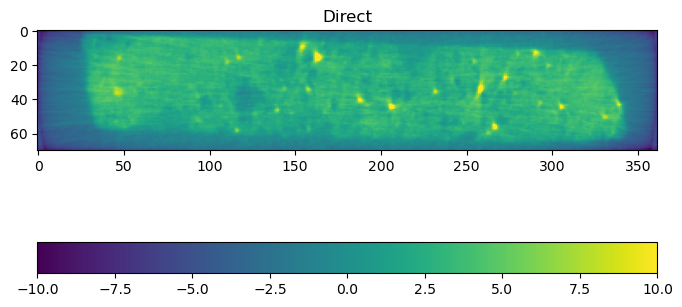

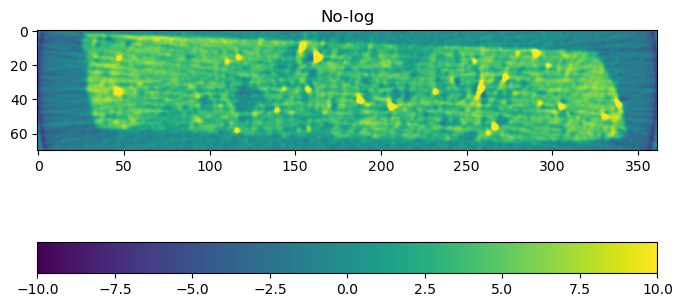

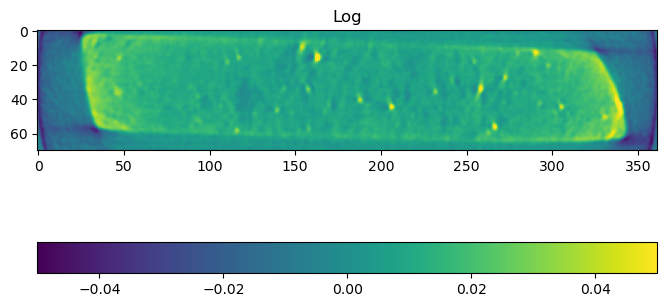

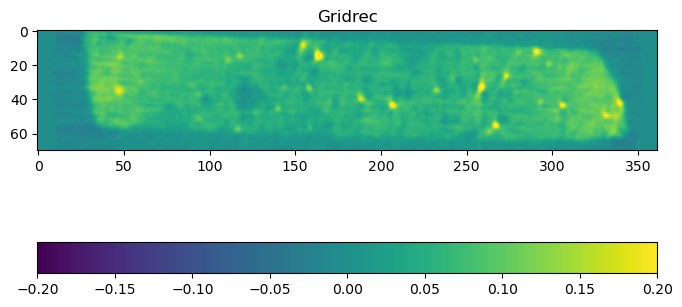

In [172]:
plt.figure(figsize=(8,8))
plt.imshow(recon[0]*1e+6)
plt.clim([-10,10])
plt.colorbar(orientation='horizontal')
plt.title('Direct')
#plt.clim([-50000,50000])
plt.show()
plt.figure(figsize=(8,8))
plt.imshow(recon_nolog[0]*1e6)
plt.colorbar(orientation='horizontal')
plt.title('No-log')
plt.clim([-10,10])
plt.show()
plt.figure(figsize=(8,8))
plt.imshow(recon_log[0])
plt.title('Log')
plt.clim([-0.05,0.05])
plt.colorbar(orientation='horizontal')
plt.show()
plt.figure(figsize=(8,8))
plt.imshow(recon_gridrec[0])
plt.title('Gridrec')
plt.clim([-0.2,0.2])
plt.colorbar(orientation='horizontal')
plt.show()

In [98]:
def mean_correlation(A1: np.ndarray, A2: np.ndarray) -> float:
    """
    Computes the mean correlation between corresponding data points A1[:, i, j] and A2[:, i, j].

    Parameters:
    A1, A2 (np.ndarray): Input 3D arrays with shape (d, n, n).

    Returns:
    float: Mean correlation over all (i, j) positions.
    """
    if A1.shape != A2.shape:
        raise ValueError("A1 and A2 must have the same shape")
    
    d, n, m = A1.shape
    correlations = np.zeros((n, m))
    
    for i in range(n):
        for j in range(m):
            corr = np.corrcoef(A1[:, i, j], A2[:, i, j])[0, 1]  # Compute correlation
            correlations[i, j] = corr if not np.isnan(corr) else 0  # Handle NaN values
    
    return np.mean(correlations)

In [ ]:
print(recon_log.shape)
print(mean_correlation(recon_gridrec, recon_nolog))
print(mean_correlation(recon_gridrec, recon_log))
print(mean_correlation(recon_gridrec, recon))
print(mean_correlation(recon, recon_log))
print(mean_correlation(recon, recon_nolog))



(200, 70, 362)


/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


0.8470901045033972
0.6852320203713564
0.6948106939474366
0.6896855418157362
0.80276022711673
